In [ ]:
import pandas as pd

In [28]:
data_train = pd.read_csv("./Datasets/Titanic/train.csv")
data_test_x = pd.read_csv("./Datasets/Titanic/test.csv")
data_test_y = pd.read_csv("./Datasets/Titanic/gender_submission.csv")

print(data_train.to_string())

     PassengerId  Survived  Pclass                                                                                Name     Sex    Age  SibSp  Parch              Ticket      Fare            Cabin Embarked
0              1         0       3                                                             Braund, Mr. Owen Harris    male  22.00      1      0           A/5 21171    7.2500              NaN        S
1              2         1       1                                 Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female  38.00      1      0            PC 17599   71.2833              C85        C
2              3         1       3                                                              Heikkinen, Miss. Laina  female  26.00      0      0    STON/O2. 3101282    7.9250              NaN        S
3              4         1       1                                        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.00      1      0              113803   53.1000       

# Cleaning Dataset

## Removing unrealated Columns

In [4]:

cleaned_data_train = data_train.drop(columns=["Name"])
cleaned_data_train

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,male,26.0,0,0,111369,30.0000,C148,C


## Changing genders to numbers

In [5]:
cleaned_data_train = cleaned_data_train.rename(columns={"Sex": "isFemale"})

In [6]:
# for i in range(len(cleaned_data_train)):
#     if cleaned_data_train.loc[i, "isFemale"] == "female":
#         cleaned_data_train.loc[i, "isFemale"] = 1
#     else:
#         cleaned_data_train.loc[i, "isFemale"] = 0

# print(cleaned_data_train.to_string())

cleaned_data_train["isFemale"] = (cleaned_data_train["isFemale"] == 'female').astype(int)

print(cleaned_data_train.to_string())

     PassengerId  Survived  Pclass  isFemale    Age  SibSp  Parch              Ticket      Fare            Cabin Embarked
0              1         0       3         0  22.00      1      0           A/5 21171    7.2500              NaN        S
1              2         1       1         1  38.00      1      0            PC 17599   71.2833              C85        C
2              3         1       3         1  26.00      0      0    STON/O2. 3101282    7.9250              NaN        S
3              4         1       1         1  35.00      1      0              113803   53.1000             C123        S
4              5         0       3         0  35.00      0      0              373450    8.0500              NaN        S
5              6         0       3         0    NaN      0      0              330877    8.4583              NaN        Q
6              7         0       1         0  54.00      0      0               17463   51.8625              E46        S
7              8        

## Cleaning age NaN

In [7]:
age_mean = cleaned_data_train["Age"].mean().round()

cleaned_data_train['Age'] = cleaned_data_train["Age"].fillna(age_mean)
print(cleaned_data_train.to_string())

     PassengerId  Survived  Pclass  isFemale    Age  SibSp  Parch              Ticket      Fare            Cabin Embarked
0              1         0       3         0  22.00      1      0           A/5 21171    7.2500              NaN        S
1              2         1       1         1  38.00      1      0            PC 17599   71.2833              C85        C
2              3         1       3         1  26.00      0      0    STON/O2. 3101282    7.9250              NaN        S
3              4         1       1         1  35.00      1      0              113803   53.1000             C123        S
4              5         0       3         0  35.00      0      0              373450    8.0500              NaN        S
5              6         0       3         0  30.00      0      0              330877    8.4583              NaN        Q
6              7         0       1         0  54.00      0      0               17463   51.8625              E46        S
7              8        

In [8]:
print(cleaned_data_train)

     PassengerId  Survived  Pclass  isFemale   Age  SibSp  Parch  \
0              1         0       3         0  22.0      1      0   
1              2         1       1         1  38.0      1      0   
2              3         1       3         1  26.0      0      0   
3              4         1       1         1  35.0      1      0   
4              5         0       3         0  35.0      0      0   
..           ...       ...     ...       ...   ...    ...    ...   
886          887         0       2         0  27.0      0      0   
887          888         1       1         1  19.0      0      0   
888          889         0       3         1  30.0      1      2   
889          890         1       1         0  26.0      0      0   
890          891         0       3         0  32.0      0      0   

               Ticket     Fare Cabin Embarked  
0           A/5 21171   7.2500   NaN        S  
1            PC 17599  71.2833   C85        C  
2    STON/O2. 3101282   7.9250   NaN   

## Cleaning the Ticket Column

In [9]:
ticket_counts = cleaned_data_train["Ticket"].value_counts()
cleaned_data_train['Ticket Group Size'] = cleaned_data_train['Ticket'].map(ticket_counts)

cleaned_data_train

,PassengerId,Survived,Pclass,isFemale,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Ticket Group Size
0,1,0,3,0,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,1,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,1,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,0,35.0,0,0,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,0,27.0,0,0,211536,13.0000,NaN,S,1
887,888,1,1,1,19.0,0,0,112053,30.0000,B42,S,1
888,889,0,3,1,30.0,1,2,W./C. 6607,23.4500,NaN,S,2
889,890,1,1,0,26.0,0,0,111369,30.0000,C148,C,1


## Removing the Ticket Column

In [10]:
cleaned_data_train = cleaned_data_train.drop("Ticket", axis="columns")
cleaned_data_train

,PassengerId,Survived,Pclass,isFemale,Age,SibSp,Parch,Fare,Cabin,Embarked,Ticket Group Size
0,1,0,3,0,22.0,1,0,7.2500,NaN,S,1
1,2,1,1,1,38.0,1,0,71.2833,C85,C,1
2,3,1,3,1,26.0,0,0,7.9250,NaN,S,1
3,4,1,1,1,35.0,1,0,53.1000,C123,S,2
4,5,0,3,0,35.0,0,0,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,0,27.0,0,0,13.0000,NaN,S,1
887,888,1,1,1,19.0,0,0,30.0000,B42,S,1
888,889,0,3,1,30.0,1,2,23.4500,NaN,S,2
889,890,1,1,0,26.0,0,0,30.0000,C148,C,1


## Cleaning Embarked

In [11]:
cleaned_data_train["Embarked"] = cleaned_data_train["Embarked"].fillna("S")

cleaned_data_train["Embarked"] = cleaned_data_train["Embarked"].astype("category").cat.codes

cleaned_data_train

,PassengerId,Survived,Pclass,isFemale,Age,SibSp,Parch,Fare,Cabin,Embarked,Ticket Group Size
0,1,0,3,0,22.0,1,0,7.2500,NaN,2,1
1,2,1,1,1,38.0,1,0,71.2833,C85,0,1
2,3,1,3,1,26.0,0,0,7.9250,NaN,2,1
3,4,1,1,1,35.0,1,0,53.1000,C123,2,2
4,5,0,3,0,35.0,0,0,8.0500,NaN,2,1
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,0,27.0,0,0,13.0000,NaN,2,1
887,888,1,1,1,19.0,0,0,30.0000,B42,2,1
888,889,0,3,1,30.0,1,2,23.4500,NaN,2,2
889,890,1,1,0,26.0,0,0,30.0000,C148,0,1


## Cleaning Cabin Column

In [12]:
cleaned_data_train["Cabin"] = cleaned_data_train["Cabin"].fillna("U")

cleaned_data_train["Cabin"] = cleaned_data_train["Cabin"].astype("category").cat.codes
cleaned_data_train

,PassengerId,Survived,Pclass,isFemale,Age,SibSp,Parch,Fare,Cabin,Embarked,Ticket Group Size
0,1,0,3,0,22.0,1,0,7.2500,147,2,1
1,2,1,1,1,38.0,1,0,71.2833,81,0,1
2,3,1,3,1,26.0,0,0,7.9250,147,2,1
3,4,1,1,1,35.0,1,0,53.1000,55,2,2
4,5,0,3,0,35.0,0,0,8.0500,147,2,1
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,0,27.0,0,0,13.0000,147,2,1
887,888,1,1,1,19.0,0,0,30.0000,30,2,1
888,889,0,3,1,30.0,1,2,23.4500,147,2,2
889,890,1,1,0,26.0,0,0,30.0000,60,0,1


## Seeing the Correlation with columns and rows

In [13]:
cleaned_data_train.corr()

,PassengerId,Survived,Pclass,isFemale,Age,SibSp,Parch,Fare,Cabin,Embarked,Ticket Group Size
PassengerId,1.000000,-0.005007,-0.035144,-0.042939,0.033019,-0.057527,-0.001652,0.012658,-0.035077,0.013128,0.003355
Survived,-0.005007,1.000000,-0.338481,0.543351,-0.070657,-0.035322,0.081629,0.257307,-0.254888,-0.167675,0.038247
Pclass,-0.035144,-0.338481,1.000000,-0.131900,-0.329727,0.083081,0.018443,-0.549500,0.684121,0.162098,-0.002633
isFemale,-0.042939,0.543351,-0.131900,1.000000,-0.084660,0.114631,0.245489,0.182333,-0.096681,-0.108262,0.154748
Age,0.033019,-0.070657,-0.329727,-0.084660,1.000000,-0.232440,-0.180330,0.090632,-0.234376,-0.028159,-0.221681
SibSp,-0.057527,-0.035322,0.083081,0.114631,-0.232440,1.000000,0.414838,0.159651,0.043593,0.068230,0.661622
Parch,-0.001652,0.081629,0.018443,0.245489,-0.180330,0.414838,1.000000,0.216225,-0.028324,0.039798,0.593076
Fare,0.012658,0.257307,-0.549500,0.182333,0.090632,0.159651,0.216225,1.000000,-0.503355,-0.224719,0.345541
Cabin,-0.035077,-0.254888,0.684121,-0.096681,-0.234376,0.043593,-0.028324,-0.503355,1.000000,0.202520,-0.027918
Embarked,0.013128,-0.167675,0.162098,-0.108262,-0.028159,0.068230,0.039798,-0.224719,0.202520,1.000000,0.049428


# --------------------------

# Training The Model

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## Seperating x & y

In [15]:
x_train = cleaned_data_train.drop("Survived", axis="columns").to_numpy()
y_train = cleaned_data_train['Survived'].to_numpy()

print(x_train, '\n', y_train)


[[  1.   3.   0. ... 147.   2.   1.]
 [  2.   1.   1. ...  81.   0.   1.]
 [  3.   3.   1. ... 147.   2.   1.]
 ...
 [889.   3.   1. ... 147.   2.   2.]
 [890.   1.   0. ...  60.   0.   1.]
 [891.   3.   0. ... 147.   1.   1.]] 
 [0 1 1 1 0 0 0 0 1 1 1 1 0 0 0 1 0 1 0 1 0 1 1 1 0 1 0 0 1 0 0 1 1 0 0 0 1
 0 0 1 0 0 0 1 1 0 0 1 0 0 0 0 1 1 0 1 1 0 1 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0
 1 0 0 0 1 1 0 1 1 0 1 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 0 0 1 0
 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1
 0 1 1 0 0 1 0 1 1 1 1 0 0 1 0 0 0 0 0 1 0 0 1 1 1 0 1 0 0 0 1 1 0 1 0 1 0
 0 0 1 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 1 1
 1 0 1 0 0 0 0 0 1 1 1 0 1 1 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0 1 1 1 1 0 0 0 0
 0 0 1 1 1 1 0 1 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 1 0 0 1 1 0 1 0 1 1 1 1 0 0
 0 1 0 0 1 1 0 1 1 0 0 0 1 1 1 1 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 1 1 1 1
 1 0 0 0 0 1 1 0 0 0

## Plotting the data

In [16]:
import matplotlib.pyplot as plt

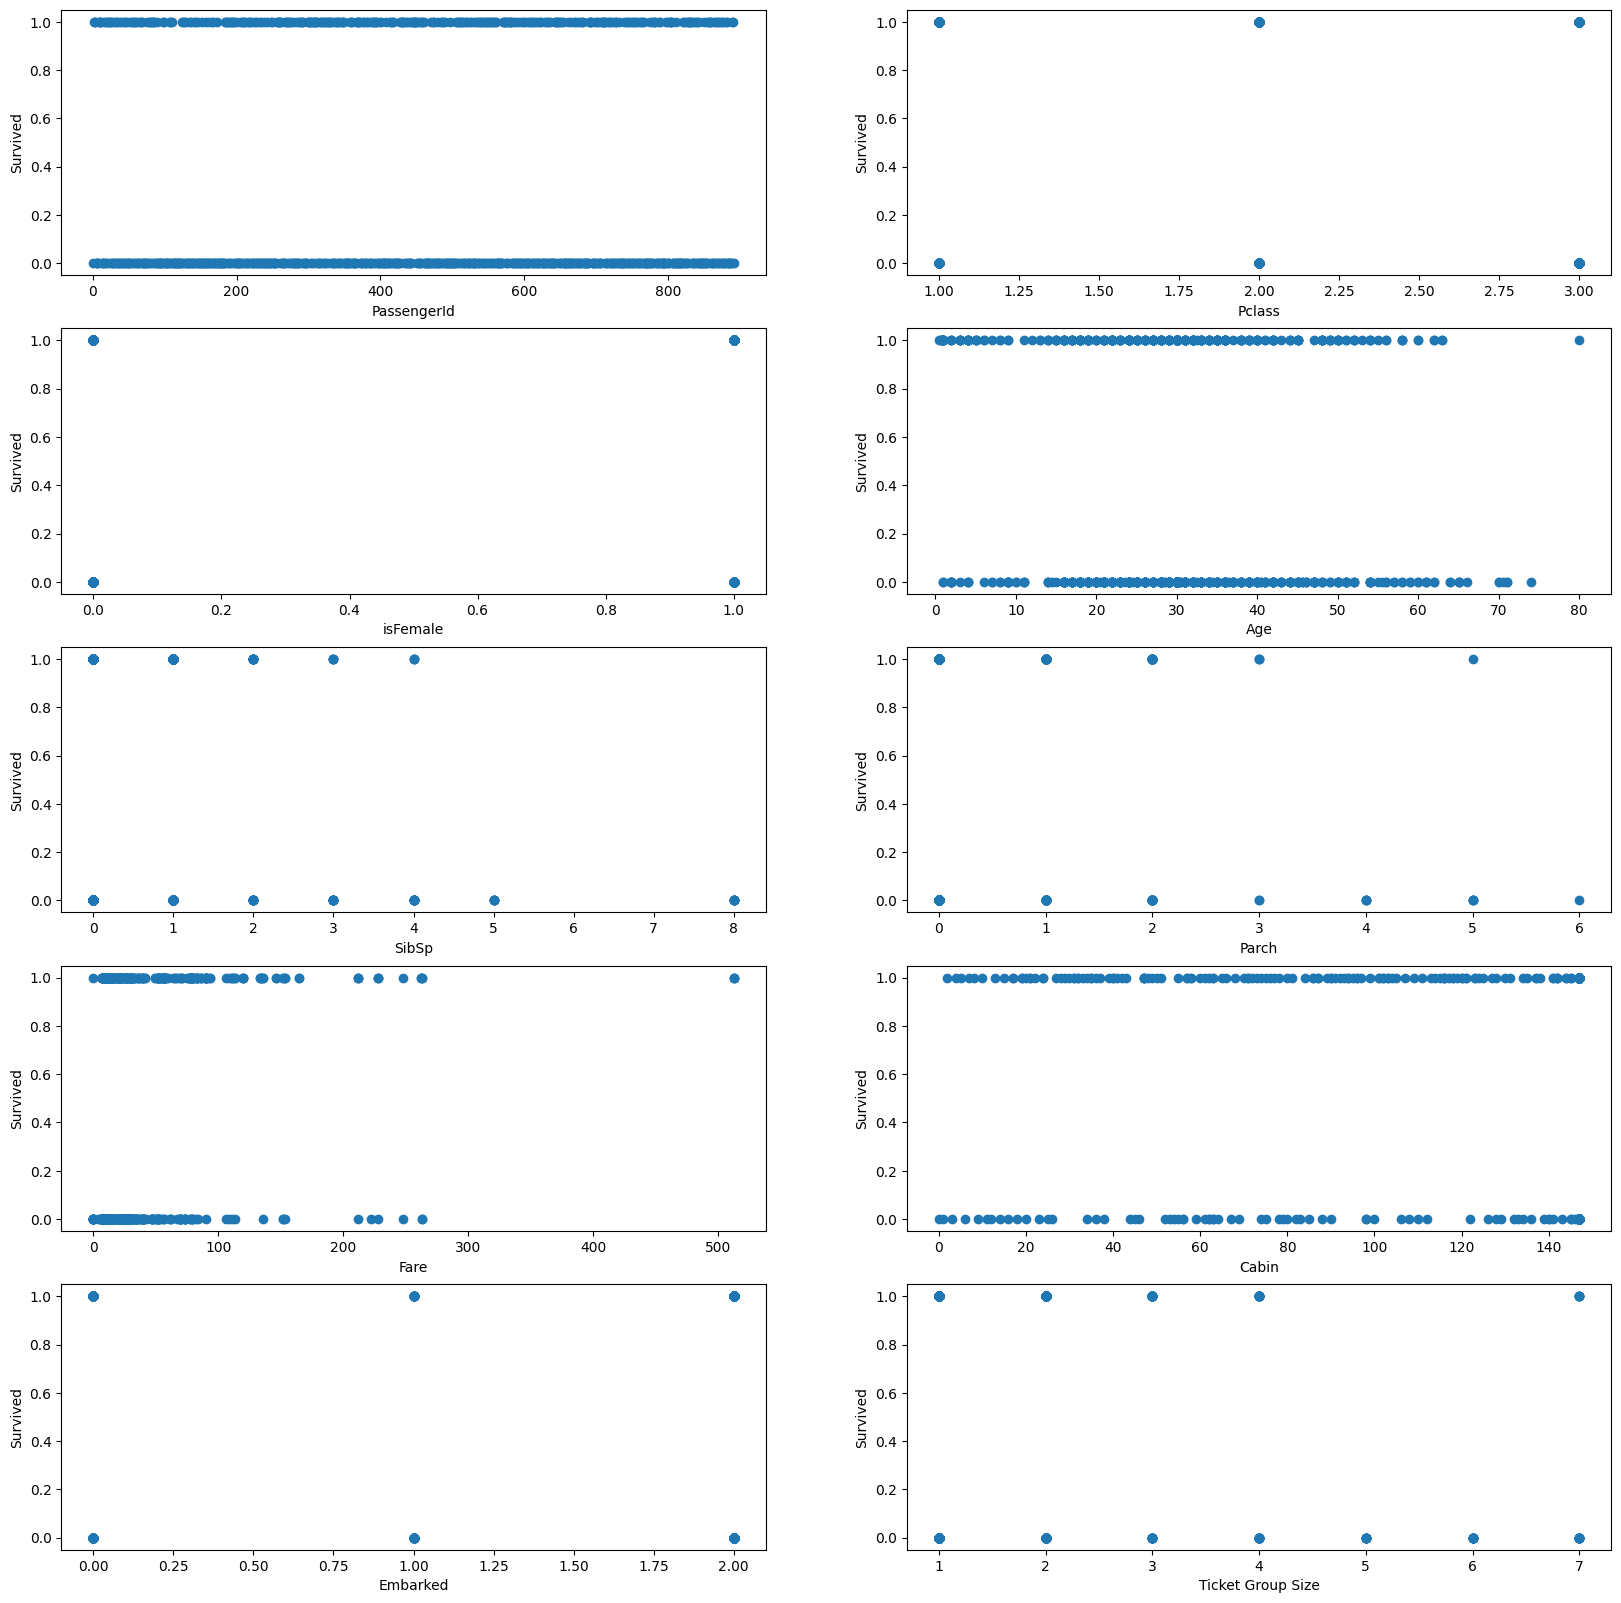

In [17]:
features = list(cleaned_data_train.columns.values)
features.remove("Survived")


fig, plot = plt.subplots(5, 2, figsize=(20, 20))
plot = plot.ravel()

for i in range(10):
    plot[i].scatter(x_train[:, i], y_train)
    plot[i].set_xlabel(features[i])
    plot[i].set_ylabel('Survived')

## Data Scaling

In [18]:
scaler = StandardScaler().fit(x_train)

x_train_scaled = scaler.transform(x_train)

print(x_train_scaled)

[[-1.73010796  0.82737724 -0.73769513 ...  0.45150219  0.58595414
  -0.57916179]
 [-1.72622007 -1.56610693  1.35557354 ... -1.38162664 -1.9423032
  -0.57916179]
 [-1.72233219  0.82737724  1.35557354 ...  0.45150219  0.58595414
  -0.57916179]
 ...
 [ 1.72233219  0.82737724  1.35557354 ...  0.45150219  0.58595414
   0.15592818]
 [ 1.72622007 -1.56610693 -0.73769513 ... -1.9648949  -1.9423032
  -0.57916179]
 [ 1.73010796  0.82737724 -0.73769513 ...  0.45150219 -0.67817453
  -0.57916179]]


In [19]:
l_regr = LogisticRegression()
l_regr.fit(x_train, y_train)

print(l_regr.score(x_train, y_train))

0.7957351290684624


C:\Users\Persian\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
from Functions import *

In [27]:
function_cleaned = clean_titanic_data(data_train)
print(function_cleaned.to_string())

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 